# 파이토치 환경 확인

In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA 사용 가능:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


# 사이킷런 다운로드

In [ ]:
!pip install -U scikit-learn

# iris 신경망 v.pt

- Iris는 데이터가 작아 CPU로 충분합니다
- device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [5]:
# 1. 재현성 고정
torch.manual_seed(1)

# 2. 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target
X.shape, y.shape

((150, 4), (150,))

In [6]:
# 3. train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

In [ ]:
# 4. X 값 스케일링 - array, 사이킷런 라이브러리
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# 5. Tensor 데이터 변환(ndarray -> torch.tensor)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [9]:
# 6. Dataset / DataLoader
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [10]:
# 7. 신경망 모델 정의
class IrisNet(nn.Module):
    def __init__(self): #신경망모델 생성자
        super().__init__()
        self.fc1 = nn.Linear(4, 16)   # 입력 특성 4개
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 3)   # 출력 클래스 3개  
              
    def forward(self, x): #순방향학습
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [11]:
model = IrisNet()
model

IrisNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

In [12]:
# 8. 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [13]:
# 9. 학습 루프
num_epochs = 100
loss_history = []  # ← 이 줄 추가

for epoch in range(num_epochs):
    model.train() #학습
    running_loss = 0.0

    for x_batch, y_batch in train_loader: #16batch
        optimizer.zero_grad()         # 기울기 초기화
        outputs = model(x_batch)      # 순전파
        loss = criterion(outputs, y_batch)  # 손실 계산
        loss.backward()               # 역전파
        optimizer.step()              # 가중치 업데이트

        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)  # ← 이 줄 추가
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")


Epoch [10/100], Loss: 0.2150
Epoch [20/100], Loss: 0.1055
Epoch [30/100], Loss: 0.0725
Epoch [40/100], Loss: 0.0674
Epoch [50/100], Loss: 0.0602
Epoch [60/100], Loss: 0.0585
Epoch [70/100], Loss: 0.0571
Epoch [80/100], Loss: 0.0493
Epoch [90/100], Loss: 0.0531
Epoch [100/100], Loss: 0.0448


In [14]:
# 10. 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.78%


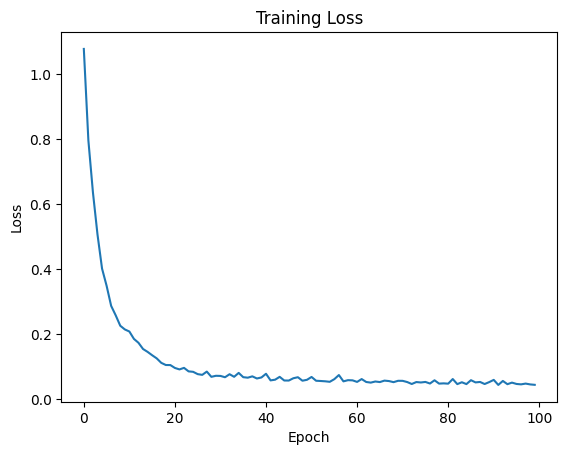

In [15]:
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

그래프 분석
전체적으로 정상입니다. 이유는 두 가지입니다.
① Loss 값이 낮음

0.04~0.07 구간에서 유지 → 이미 충분히 수렴한 상태
Epoch 10~20 이전에 빠르게 내려간 후 수평 유지

② 진동(fluctuation)이 있는 건 정상

Iris 데이터가 겨우 105개(훈련셋)라 배치마다 샘플이 달라 loss가 튑니다
batch_size=16이면 한 epoch에 배치가 7개뿐 → 통계적 노이즈가 클 수밖에 없음

# mnist 신경망 v.pt

In [ ]:
!pip install -U torchsummary

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("사용 장치:", device)

사용 장치: cuda


device 설정으로 GPU/CPU 자동 선택 패턴 도입

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [16]:
# 2. 데이터셋 로드
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [17]:
# 3. 모델 정의
import torch.nn as nn
import torch.nn.functional as F

class MnistNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [23]:
model = MnistNet().to(device)

# 4. 손실함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
# 5. 학습 루프
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


Epoch 1/10, Loss: 0.3563
Epoch 2/10, Loss: 0.1590
Epoch 3/10, Loss: 0.1141
Epoch 4/10, Loss: 0.0938
Epoch 5/10, Loss: 0.0785
Epoch 6/10, Loss: 0.0683
Epoch 7/10, Loss: 0.0594
Epoch 8/10, Loss: 0.0554
Epoch 9/10, Loss: 0.0484
Epoch 10/10, Loss: 0.0439


In [25]:
# 6. 평가
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 96.86%


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # (1, 28, 28) -> (16, 28, 28)
        self.pool = nn.MaxPool2d(2, 2)                # (16, 28, 28) -> (16, 14, 14)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # (16, 14, 14) -> (32, 14, 14)
        
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))   # 합성곱 + ReLU
        x = self.pool(x)            # 풀링
        x = F.relu(self.conv2(x))   # 합성곱 + ReLU
        x = self.pool(x)            # 풀링

        x = x.view(-1, 32 * 7 * 7)  # 펼치기
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [28]:
model = MnistCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [30]:
epochs = 5

for epoch in range(epochs):
    model.train()   # 학습 모드
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()          # 이전 기울기 초기화
        outputs = model(images)        # 예측
        loss = criterion(outputs, labels)  # 오차 계산
        loss.backward()                # 역전파
        optimizer.step()               # 가중치 업데이트

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"{epoch+1}번째 epoch, 평균 loss: {avg_loss:.4f}")

1번째 epoch, 평균 loss: 0.0196
2번째 epoch, 평균 loss: 0.0168
3번째 epoch, 평균 loss: 0.0134
4번째 epoch, 평균 loss: 0.0110
5번째 epoch, 평균 loss: 0.0094


In [31]:
model.eval()   # 평가 모드

correct = 0
total = 0

with torch.no_grad():   # 평가할 때는 기울기 계산 안 함
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"테스트 정확도: {accuracy:.2f}%")

테스트 정확도: 99.04%


In [ ]:
# transform = transforms.ToTensor()

# train_dataset = datasets.MNIST(
#     root="./data",
#     train=True,
#     download=True,
#     transform=transform
# )

# test_dataset = datasets.MNIST(
#     root="./data",
#     train=False,
#     download=True,
#     transform=transform
# )

In [15]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

batch_size=64 : 한 번에 64장씩 학습
shuffle=True : 학습 데이터 섞기
shuffle=False : 테스트는 순서 섞지 않아도 됨

nn.Sequential로 간결한 모델 표현 → 클래스 기반(IrisNet)과 대비되어 두 스타일 모두 경험 가능

In [16]:
model = nn.Sequential(
    nn.Flatten(),          # 28x28 이미지를 784칸으로 펼침
    nn.Linear(784, 128),   # 입력 784개 → 128개
    nn.ReLU(),             # 활성화 함수
    nn.Dropout(0.5),       # 일부를 끄면서 과적합 방지
    nn.Linear(128, 10)     # 10개 숫자(0~9) 출력
)

model = model.to(device)

Dropout(0.5) 포함 — 과적합 방지 개념 자연스럽게 삽입

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
epochs = 5

for epoch in range(epochs):
    model.train()   # 학습 모드로 변경
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()        # 기울기 초기화
        outputs = model(images)      # 예측값 계산
        loss = criterion(outputs, labels)  # 오차 계산
        loss.backward()              # 역전파
        optimizer.step()             # 가중치 수정

        total_loss += loss.item()

    print(f"{epoch+1}번째 학습, 평균 loss: {total_loss / len(train_loader):.4f}")

1번째 학습, 평균 loss: 0.4604
2번째 학습, 평균 loss: 0.2515
3번째 학습, 평균 loss: 0.2042
4번째 학습, 평균 loss: 0.1796
5번째 학습, 평균 loss: 0.1622


In [19]:
model.eval()   # 평가 모드로 변경

correct = 0
total = 0

with torch.no_grad():   # 테스트에서는 학습 안 함
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("테스트 정확도:", accuracy)

테스트 정확도: 96.8
